In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("saas_churn_large_100k (1).csv")
df.head()

,customer_id,tenure_months,monthly_charges,avg_monthly_usage,plan_type,payment_failures,support_tickets,last_login_days,churn
0,1,39,147.76,34.0,Basic,0,3,75,1
1,2,52,328.81,240.7,Basic,0,2,25,0
2,3,29,67.16,219.4,Standard,0,2,61,0
3,4,15,25.90,87.1,Basic,0,1,60,0
4,5,43,259.23,46.0,Premium,0,1,46,0


In [5]:
df.shape

(100000, 9)

In [6]:
df.isna().sum()

customer_id          0
tenure_months        0
monthly_charges      0
avg_monthly_usage    0
plan_type            0
payment_failures     0
support_tickets      0
last_login_days      0
churn                0
dtype: int64

In [7]:
df['churn'].value_counts(normalize=True)

churn
0    0.77773
1    0.22227
Name: proportion, dtype: float64

In [8]:
df.memory_usage(deep=True).sum() /1e6

np.float64(11.955257)

In [10]:
x = df.drop(columns =["customer_id","churn"], axis =1)
y = df["churn"]

In [11]:
x= pd.get_dummies(x, columns=["plan_type"], drop_first = True, dtype=int)

In [12]:
x.head()

,tenure_months,monthly_charges,avg_monthly_usage,payment_failures,support_tickets,last_login_days,plan_type_Premium,plan_type_Standard
0,39,147.76,34.0,0,3,75,0,0
1,52,328.81,240.7,0,2,25,0,0
2,29,67.16,219.4,0,2,61,0,1
3,15,25.90,87.1,0,1,60,0,0
4,43,259.23,46.0,0,1,46,1,0


In [13]:
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
model_1 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
model_1.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_prediction = model_1.predict(x_test)
y_proba = model_1.predict_proba(x_test)[:,1]

In [19]:
print(classification_report(y_test,y_prediction))

              precision    recall  f1-score   support

           0       0.85      0.64      0.73     15540
           1       0.33      0.62      0.43      4460

    accuracy                           0.64     20000
   macro avg       0.59      0.63      0.58     20000
weighted avg       0.74      0.64      0.67     20000



In [21]:
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC_AUC",roc_auc)

ROC_AUC 0.6977666632038828


In [23]:
feature_importance = pd.DataFrame({
    "feature": x_train.columns,
    "coefficient": model_1.coef_[0]
}).sort_values(by="coefficient",ascending=False)

feature_importance

,feature,coefficient
3,payment_failures,0.551727
5,last_login_days,0.021027
1,monthly_charges,0.000050
2,avg_monthly_usage,-0.003242
7,plan_type_Standard,-0.007493
6,plan_type_Premium,-0.008520
4,support_tickets,-0.014550
0,tenure_months,-0.015892


In [26]:
model_2 = RandomForestClassifier(
    n_estimators = 300,
    max_depth = 8,
    min_samples_split = 20,
    class_weight = "balanced",
    random_state=42
)

model_2.fit(x_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_prediction_2 = model_2.predict(x_test)
y_proba_2 = model_2.predict_proba(x_test)[:,1]

print(classification_report(y_test,y_prediction_2))
print("ROC-AUC",roc_auc_score(y_test,y_proba_2))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83     15540
           1       0.44      0.54      0.49      4460

    accuracy                           0.75     20000
   macro avg       0.65      0.67      0.66     20000
weighted avg       0.77      0.75      0.76     20000

ROC-AUC 0.7534965242308291


In [31]:
feature_importance_1 = pd.DataFrame({
    "feature" : x.columns,
    "importance" : model_2.feature_importances_
}).sort_values(by="importance",ascending=False)

feature_importance_1.head(20)

,feature,importance
5,last_login_days,0.361606
3,payment_failures,0.258262
0,tenure_months,0.196539
2,avg_monthly_usage,0.162074
1,monthly_charges,0.015197
4,support_tickets,0.004203
6,plan_type_Premium,0.001115
7,plan_type_Standard,0.001005


In [33]:
model_comparison = pd.DataFrame({
    "Model":["Logistic Regression", "Random Forest"],
    "ROC-AUC": [0.697, roc_auc_score(y_test,y_proba_2)]
})

model_comparison

,Model,ROC-AUC
0,Logistic Regression,0.697000
1,Random Forest,0.753497


In [39]:
# shap analysis
RETENTION_OFFER_COST = 50        #cost of saving a customer
Months_saved_if_retained = 6     #expected months of revenue
RETENTION_SUCCESS_RATE = 0.3     #% of targeted churners

In [40]:
test_eval = x_test.copy()
test_eval["actual_churn"] = y_test.values
test_eval["proba_churn"] = y_proba_2

test_eval["monthly_revenue"] = test_eval["monthly_charges"]

test_eval["value_if_saved"] = test_eval["monthly_revenue"]*Months_saved_if_retained

In [41]:
def simulate_threshold(test_eval, threshold):
    targeted = test_eval["proba_churn"] >= threshold
    
    # Costs: we pay offer cost for everyone we target
    cost = targeted.sum() * RETENTION_OFFER_COST
    
    # Benefits: only churners can be saved, and only at success rate
    churners_targeted = test_eval[targeted & (test_eval["actual_churn"] == 1)]
    benefit = churners_targeted["value_if_saved"].sum() * RETENTION_SUCCESS_RATE
    
    net = benefit - cost
    
    return {
        "threshold": threshold,
        "targeted_customers": int(targeted.sum()),
        "churners_targeted": int((targeted & (test_eval["actual_churn"] == 1)).sum()),
        "cost": float(cost),
        "benefit": float(benefit),
        "net_savings": float(net)
    }

In [42]:
thresholds = np.arange(0.05, 0.95, 0.01)

results = [simulate_threshold(test_eval, t) for t in thresholds]
results_df = pd.DataFrame(results).sort_values("net_savings", ascending=False)

results_df.head(10)

,threshold,targeted_customers,churners_targeted,cost,benefit,net_savings
11,0.16,15248,4460,762400.0,2067148.494,1304748.494
9,0.14,15249,4460,762450.0,2067148.494,1304698.494
7,0.12,15249,4460,762450.0,2067148.494,1304698.494
8,0.13,15249,4460,762450.0,2067148.494,1304698.494
10,0.15,15249,4460,762450.0,2067148.494,1304698.494
6,0.11,15252,4460,762600.0,2067148.494,1304548.494
31,0.36,15241,4459,762050.0,2066353.722,1304303.722
30,0.35,15243,4459,762150.0,2066353.722,1304203.722
5,0.10,15259,4460,762950.0,2067148.494,1304198.494
29,0.34,15244,4459,762200.0,2066353.722,1304153.722


In [44]:
best = results_df.iloc[0]
best_threshold = best["threshold"]

best, best_threshold

(threshold                   0.160
 targeted_customers      15248.000
 churners_targeted        4460.000
 cost                   762400.000
 benefit               2067148.494
 net_savings           1304748.494
 Name: 11, dtype: float64,
 np.float64(0.16000000000000003))

In [45]:
# Baseline loss if we do nothing (assume every churner leaves)
baseline_loss = test_eval.loc[test_eval["actual_churn"] == 1, "value_if_saved"].sum()

# Loss after intervention (baseline loss minus expected saved benefit)
loss_after = baseline_loss - best["benefit"]

summary = {
    "baseline_expected_loss": float(baseline_loss),
    "expected_benefit_saved": float(best["benefit"]),
    "intervention_cost": float(best["cost"]),
    "net_savings": float(best["net_savings"]),
    "optimal_threshold": float(best_threshold),
    "customers_targeted": int(best["targeted_customers"])
}

summary

{'baseline_expected_loss': 6890494.98,
 'expected_benefit_saved': 2067148.494,
 'intervention_cost': 762400.0,
 'net_savings': 1304748.494,
 'optimal_threshold': 0.16000000000000003,
 'customers_targeted': 15248}

In [46]:
!pip install shap

  Using cached shap-0.50.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.50.0-cp313-cp313-win_amd64.whl (549 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [49]:
import shap

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(model_2)

# For speed, use a sample if needed
X_sample = x_test.sample(2000, random_state=42)  # increase/decrease if your machine is slow
shap_values = explainer.shap_values(X_sample)

In [50]:
shap.summary_plot(shap_values[1], X_sample)  

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [51]:
print("X_sample:", X_sample.shape)
print("type shap_values:", type(shap_values))
print("has .values:", hasattr(shap_values, "values"))
if hasattr(shap_values, "values"):
    print("shap_values.values:", shap_values.values.shape)
elif isinstance(shap_values, list):
    print([sv.shape for sv in shap_values])
else:
    print("shap_values:", shap_values.shape)

X_sample: (2000, 8)
type shap_values: <class 'numpy.ndarray'>
has .values: False
shap_values: (2000, 8, 2)


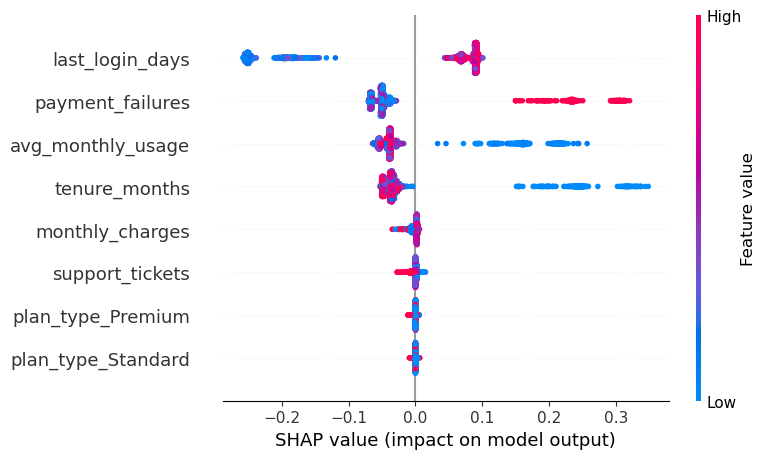

In [52]:
# class 1
shap.summary_plot(shap_values[:, :, 1], X_sample)

# (optional) class 0
# shap.summary_plot(shap_values[:, :, 0], X_sample)